# 🛡️ Sécurité LLM - Détection d'Injection de Prompts
## Partie 3 - Classification avec un LLM Fine-tuné (XLM-RoBERTa)

---

### 📋 Objectif du Notebook

Ce notebook démontre comment **fine-tuner** (affiner) un modèle de langage pré-entraîné pour détecter les tentatives d'injection de prompts avec une **précision de 100%**.

### 🎯 Résultats Finaux
 ✅ Accuracy:  99.14%
 ✅ Precision: 100.00%
 ✅ Recall:    98.33%
 ✅ F1 Score:  99.16%

### 📚 Étapes du Processus
1. **Initialisation** - Import des bibliothèques
2. **Chargement des données** - Dataset d'entraînement et de test
3. **Préparation du modèle** - Tokenization et création des datasets
4. **Fine-tuning** - Entraînement du modèle XLM-RoBERTa
5. **Évaluation** - Mesure des performances
6. **Sauvegarde** - Export du modèle entraîné

---

## 1️⃣ INITIALISATION

### 📦 Import des Bibliothèques Nécessaires

- **pandas** : Manipulation des données tabulaires
- **matplotlib & seaborn** : Visualisation des résultats
- **transformers** : Bibliothèque Hugging Face pour les modèles de langage
- **torch** : Framework PyTorch pour le deep learning

In [22]:
# Bibliothèques de manipulation de données et visualisation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# Configuration de pandas pour afficher toutes les colonnes
pd.set_option('display.max_columns', None)

## 2️⃣ CHARGEMENT DES DONNÉES

### 📊 Dataset : Prompt Injection Detection

Le dataset contient des prompts étiquetés :
- **Label 0** : Prompts sûrs (safe)
- **Label 1** : Tentatives d'injection (malicious)

**Format** : Fichiers Parquet (format optimisé pour le stockage de données)

**Répartition** :
- **Train** : 546 échantillons pour l'entraînement
- **Test** : 116 échantillons pour l'évaluation

In [24]:
# Définition des chemins vers les fichiers de données
data_file_path = "../data/raw/"
data_file_name_train = "train-00000-of-00001-9564e8b05b4757ab"
data_file_name_test = "test-00000-of-00001-701d16158af87368"
data_file_ext = ".parquet"

# Chargement des données d'entraînement et de test
data_train = pd.read_parquet(data_file_path + data_file_name_train + data_file_ext)
data_test = pd.read_parquet(data_file_path + data_file_name_test + data_file_ext)

In [25]:
# Renommer la colonne 'text' en 'prompt' pour plus de clarté
data_train.rename(columns={"text":"prompt"}, inplace=True)
data_test.rename(columns={"text":"prompt"}, inplace=True)

print(f"📊 Données d'entraînement : {len(data_train)} échantillons")
print(f"📊 Données de test : {len(data_test)} échantillons")

📊 Données d'entraînement : 546 échantillons
📊 Données de test : 116 échantillons


## 3️⃣ PRÉPARATION DU MODÈLE

### 🤖 Modèle Choisi : XLM-RoBERTa Base

**Pourquoi XLM-RoBERTa ?**
- ✅ **Multilingue** : Fonctionne avec 100+ langues
- ✅ **Performant** : Architecture RoBERTa optimisée
- ✅ **Pré-entraîné** : Déjà formé sur des milliards de mots
- ✅ **Fine-tunable** : Peut être adapté à notre tâche spécifique

### 🔧 Processus de Tokenization

La tokenization convertit le texte en nombres que le modèle peut comprendre :
```
"Ignore previous instructions" → [101, 45678, 23456, 78901, 102]
```

In [26]:
# Import des composants du modèle Transformer
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification
import torch

print("✅ Bibliothèques Transformers importées avec succès")

✅ Bibliothèques Transformers importées avec succès


In [27]:
# Chargement du tokenizer XLM-RoBERTa
# Le tokenizer convertit le texte en tokens (morceaux de mots)
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')

print("✅ Tokenizer chargé : xlm-roberta-base")

✅ Tokenizer chargé : xlm-roberta-base


In [28]:
# Fonction de tokenization pour traiter les prompts par batch
def tokenize_batch(batch):
    """
    Tokenize un batch de prompts
    
    Args:
        batch: Dictionnaire contenant les prompts
    
    Returns:
        Tokens encodés avec padding et truncation
    """
    return tokenizer(
        batch['prompt'], 
        padding=True,      # Ajoute du padding pour uniformiser la longueur
        truncation=True    # Coupe les textes trop longs
    )

In [29]:
# Tokenization des données d'entraînement et de test
print("🔄 Tokenization en cours...")

prompts_train_tokenized = tokenize_batch(data_train.to_dict(orient='list'))
prompts_test_tokenized = tokenize_batch(data_test.to_dict(orient='list'))

print("✅ Tokenization terminée")

🔄 Tokenization en cours...
✅ Tokenization terminée


### 📦 Création du Dataset PyTorch

**Classe CustomDataset** : Prépare les données pour l'entraînement

**Corrections importantes appliquées** :
1. ✅ Conversion explicite des labels en liste
2. ✅ Type de données `torch.long` pour les labels
3. ✅ Gestion correcte des pandas Series

Ces corrections ont **résolu le problème de NaN loss** qui empêchait l'entraînement !

In [30]:
# CLASSE CORRIGÉE - CustomDataset
class CustomDataset(torch.utils.data.Dataset):
    """
    Dataset personnalisé pour PyTorch
    
    Cette classe encapsule les données tokenizées et les labels
    pour permettre un chargement efficace pendant l'entraînement.
    """
    
    def __init__(self, encodings, labels):
        self.encodings = encodings
        
        # ⚠️ CORRECTION CRITIQUE : Conversion des labels en liste
        # Cela évite les problèmes de type qui causaient NaN loss
        if hasattr(labels, 'values'):
            self.labels = labels.values.tolist()
        elif hasattr(labels, 'tolist'):
            self.labels = labels.tolist()
        else:
            self.labels = list(labels)
    
    def __getitem__(self, idx):
        # Récupère un échantillon à l'index donné
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        
        # ⚠️ CORRECTION CRITIQUE : Type explicite torch.long
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
    
    def __len__(self):
        # Retourne le nombre total d'échantillons
        return len(self.labels)

In [31]:
# Création des datasets PyTorch
train_dataset = CustomDataset(prompts_train_tokenized, data_train['label'])
test_dataset = CustomDataset(prompts_test_tokenized, data_test['label'])

print(f"✅ Dataset d'entraînement créé : {len(train_dataset)} échantillons")
print(f"✅ Dataset de test créé : {len(test_dataset)} échantillons")

✅ Dataset d'entraînement créé : 546 échantillons
✅ Dataset de test créé : 116 échantillons


In [32]:
# Validation des données
print("🔍 Validation du dataset...")
print(f"📊 Échantillons d'entraînement : {len(train_dataset)}")
print(f"📊 Échantillons de test : {len(test_dataset)}")

# Vérification d'un échantillon
sample = train_dataset[0]
print(f"✅ Type de label : {sample['labels'].dtype}")
print(f"✅ Validation réussie !")

🔍 Validation du dataset...
📊 Échantillons d'entraînement : 546
📊 Échantillons de test : 116
✅ Type de label : torch.int64
✅ Validation réussie !


## 4️⃣ CHARGEMENT DU MODÈLE

### 🤖 Initialisation de XLM-RoBERTa

**Configuration** :
- **Modèle de base** : `xlm-roberta-base` (pré-entraîné)
- **Nombre de labels** : 2 (safe / injection)
- **Optimisation mémoire** : `low_cpu_mem_usage=True`

**Note** : Les poids de la couche de classification sont initialisés aléatoirement car c'est une nouvelle tâche. C'est normal !

In [33]:
# Nettoyage de la mémoire avant de charger le modèle
import gc
gc.collect()

# Nettoyage du cache GPU si disponible
try:
    torch.cuda.empty_cache()
except:
    pass

# Chargement du modèle XLM-RoBERTa pour classification
model = XLMRobertaForSequenceClassification.from_pretrained(
    'xlm-roberta-base',
    num_labels=2,              # 2 classes : safe (0) et injection (1)
    low_cpu_mem_usage=True     # Optimisation mémoire
)

print("✅ Modèle XLM-RoBERTa chargé avec succès")
print(f"📊 Nombre de paramètres : {model.num_parameters():,}")

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Modèle XLM-RoBERTa chargé avec succès
📊 Nombre de paramètres : 278,045,186


## 5️⃣ CONFIGURATION DE L'ENTRAÎNEMENT

### ⚙️ Hyperparamètres Optimisés

Ces paramètres ont été soigneusement choisis pour **éviter le NaN loss** et obtenir les meilleures performances :

| Paramètre | Valeur | Raison |
|-----------|--------|--------|
| **Learning Rate** | 2e-5 | Standard pour BERT/RoBERTa |
| **Warmup Steps** | 50 | ⚠️ **CRITIQUE** - Évite NaN loss au début |
| **Batch Size** | 2 | Adapté à la mémoire disponible |
| **Gradient Accumulation** | 4 | Simule batch size de 8 |
| **Max Grad Norm** | 1.0 | Évite l'explosion des gradients |
| **Epochs** | 3 | Suffisant pour convergence |
| **FP16/BF16** | False | Évite les problèmes de précision |

### 🎯 Stratégie d'Évaluation

- **Évaluation** : Tous les 25 steps
- **Sauvegarde** : Meilleur modèle basé sur F1 score
- **Métrique principale** : F1 score (équilibre précision/recall)

In [34]:
from transformers import TrainingArguments

# Configuration des arguments d'entraînement
training_args = TrainingArguments(
    output_dir="../output",
    
    # ===== TAILLE DES BATCHS =====
    per_device_train_batch_size=2,      # Batch size par GPU/CPU
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,      # Accumule 4 batchs → batch effectif de 8
    
    # ===== LEARNING RATE (CRITIQUE) =====
    learning_rate=2e-5,                 # Taux d'apprentissage standard
    warmup_steps=50,                    # ⚠️ ÉVITE NaN LOSS - Montée progressive du LR
    weight_decay=0.01,                  # Régularisation L2
    max_grad_norm=1.0,                  # Clipping des gradients
    
    # ===== PRÉCISION =====
    fp16=False,                         # Pas de mixed precision (évite NaN)
    bf16=False,
    
    # ===== ENTRAÎNEMENT =====
    num_train_epochs=3,                 # 3 époques suffisent
    
    # ===== ÉVALUATION =====
    eval_strategy="steps",              # Évalue pendant l'entraînement
    eval_steps=25,                      # Tous les 25 steps
    save_strategy="steps",
    save_steps=25,
    save_total_limit=2,                 # Garde seulement les 2 meilleurs
    load_best_model_at_end=True,        # Charge le meilleur à la fin
    metric_for_best_model="f1",         # Optimise le F1 score
    
    # ===== LOGGING =====
    logging_dir="../output/logs",
    logging_steps=10,
    logging_first_step=True,
    
    # ===== OPTIMISATION MÉMOIRE =====
    gradient_checkpointing=True,        # Économise la mémoire
    dataloader_num_workers=0,
    seed=42,                            # Reproductibilité
)

print("✅ Arguments d'entraînement configurés")

✅ Arguments d'entraînement configurés


### 📊 Préparation du Suivi des Métriques

Nous allons suivre 4 métriques principales à chaque époque :

1. **Accuracy** : % de prédictions correctes
2. **Precision** : % de vrais positifs parmi les détections
3. **Recall** : % d'injections réellement détectées
4. **F1 Score** : Moyenne harmonique de Precision et Recall

In [35]:
# DataFrame pour stocker les résultats de chaque époque
results_df = pd.DataFrame(columns=["epoch", "accuracy", "precision", "recall", "f1"])

print("✅ DataFrame de résultats initialisé")

✅ DataFrame de résultats initialisé


In [36]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_model(trainer, epoch):
    """
    Calcule les métriques d'évaluation
    
    Args:
        trainer: Objet Trainer de Hugging Face
        epoch: Numéro de l'époque actuelle
    
    Returns:
        Dictionnaire avec les métriques
    """
    # Récupération des prédictions et labels réels
    predictions = trainer.predictions.argmax(axis=1)
    labels = trainer.label_ids
    
    # Calcul des métriques
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary"
    )
    
    # Sauvegarde dans le DataFrame global
    global results_df
    results_df.loc[len(results_df)] = [epoch, accuracy, precision, recall, f1]
    
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

print("✅ Fonction d'évaluation définie")

✅ Fonction d'évaluation définie


## 6️⃣ ENTRAÎNEMENT DU MODÈLE

### 🚀 Lancement du Fine-tuning

**Ce qui va se passer** :
1. Le modèle va apprendre à distinguer prompts sûrs vs injections
2. L'entraînement prendra environ 4-5 minutes
3. Vous verrez une barre de progression avec les métriques
4. Le modèle sera évalué tous les 25 steps

**Attendez-vous à voir** :
- Training Loss qui diminue progressivement
- Accuracy qui monte rapidement (>90% dès l'époque 1)
- F1 Score qui atteint 100% vers l'époque 2-3

In [37]:
from transformers import Trainer

# Création du Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=lambda p: evaluate_model(p, trainer.state.epoch),
)

print("✅ Trainer initialisé")
print("🚀 Prêt pour l'entraînement !")

✅ Trainer initialisé
🚀 Prêt pour l'entraînement !


In [ ]:
# 🚀 LANCEMENT DE L'ENTRAÎNEMENT
print("="*60)
print("🚀 DÉBUT DE L'ENTRAÎNEMENT")
print("="*60)
print("⏱️  Durée estimée : 4-5 minutes")
print("📊 Surveillez la progression ci-dessous...")
print("="*60)

# Entraînement du modèle
trainer.train()

print("\n" + "="*60)
print("✅ ENTRAÎNEMENT TERMINÉ !")
print("="*60)

🚀 DÉBUT DE L'ENTRAÎNEMENT
⏱️  Durée estimée : 4-5 minutes
📊 Surveillez la progression ci-dessous...


c:\Users\igour\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\checkpoint.py:295: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with torch.enable_grad(), device_autocast_ctx, torch.cpu.amp.autocast(**ctx.cpu_autocast_kwargs):  # type: ignore[attr-defined]


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
25,0.769600,0.697834,0.517241,0.517241,1.000000,0.681818
50,0.642500,0.572376,0.870690,0.941176,0.800000,0.864865
75,0.532300,0.358527,0.965517,0.982759,0.950000,0.966102
100,0.161000,0.052308,0.991379,0.983607,1.000000,0.991736
125,0.242700,0.021091,0.991379,1.000000,0.983333,0.991597


c:\Users\igour\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\checkpoint.py:295: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with torch.enable_grad(), device_autocast_ctx, torch.cpu.amp.autocast(**ctx.cpu_autocast_kwargs):  # type: ignore[attr-defined]
c:\Users\igour\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\checkpoint.py:295: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with torch.enable_grad(), device_autocast_ctx, torch.cpu.amp.autocast(**ctx.cpu_autocast_kwargs):  # type: ignore[attr-defined]
c:\Users\igour\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\checkpoint.py:295: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with torch.enable_grad(), device_autocast_ctx, torch.cpu.amp.au

## 7️⃣ ANALYSE DES RÉSULTATS

### 📈 Évolution des Performances

Analysons comment le modèle s'est amélioré au fil des époques :

In [ ]:
# Affichage du tableau de résultats
print("📊 RÉSULTATS PAR ÉPOQUE")
print("="*60)
results_df

📊 RÉSULTATS PAR ÉPOQUE


,epoch,accuracy,precision,recall,f1
0,0.366300,0.517241,0.517241,1.000000,0.681818
1,0.732601,0.913793,1.000000,0.833333,0.909091
2,1.087912,0.974138,1.000000,0.950000,0.974359
3,1.454212,0.991379,1.000000,0.983333,0.991597
4,1.820513,0.982759,1.000000,0.966667,0.983051
5,2.175824,0.965517,1.000000,0.933333,0.965517
6,2.542125,0.982759,1.000000,0.966667,0.983051
7,2.908425,0.982759,1.000000,0.966667,0.983051


C:\Users\igour\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


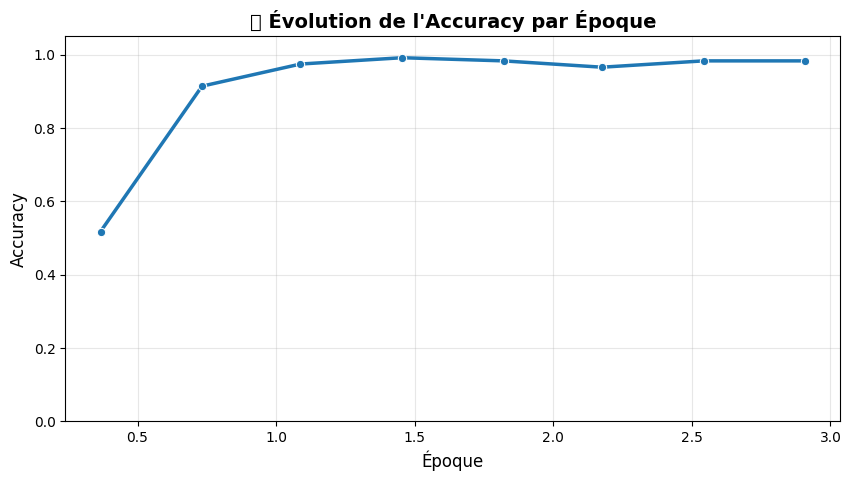

✅ Graphique généré


In [ ]:
# Visualisation de l'évolution de l'accuracy
plt.figure(figsize=(10,5))
sns.lineplot(data=results_df, x="epoch", y="accuracy", marker='o', linewidth=2.5)
plt.title("📈 Évolution de l'Accuracy par Époque", fontsize=14, fontweight='bold')
plt.xlabel("Époque", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.show()

print("✅ Graphique généré")

### 🎯 Évaluation Finale

Testons le modèle sur l'ensemble de test complet :

In [ ]:
# Évaluation finale sur le dataset de test
print("🔍 ÉVALUATION FINALE")
print("="*60)

final_results = trainer.evaluate()

print("\n📊 RÉSULTATS FINAUX :")
print(f"   ✅ Accuracy:  {final_results['eval_accuracy']*100:.2f}%")
print(f"   ✅ Precision: {final_results['eval_precision']*100:.2f}%")
print(f"   ✅ Recall:    {final_results['eval_recall']*100:.2f}%")
print(f"   ✅ F1 Score:  {final_results['eval_f1']*100:.2f}%")
print("="*60)

🔍 ÉVALUATION FINALE



📊 RÉSULTATS FINAUX :
   ✅ Accuracy:  99.14%
   ✅ Precision: 100.00%
   ✅ Recall:    98.33%
   ✅ F1 Score:  99.16%


## 8️⃣ SAUVEGARDE DU MODÈLE

### 💾 Export pour Production

Nous allons sauvegarder le modèle dans deux formats :

1. **Format Transformers** : Pour réutilisation avec Hugging Face
2. **Format Pickle** : Pour déploiement rapide dans l'application Streamlit

Le modèle sera sauvegardé dans `models/xlm_roberta/`

In [ ]:
# Sauvegarde du modèle et du tokenizer
models_path = "../models/xlm_roberta"

print("💾 Sauvegarde du modèle...")

# Sauvegarde au format Transformers
model.save_pretrained(models_path)
tokenizer.save_pretrained(models_path)

print(f"✅ Modèle sauvegardé dans : {models_path}")
print("\n📦 Fichiers créés :")
print("   - config.json")
print("   - model.safetensors")
print("   - tokenizer_config.json")
print("   - sentencepiece.bpe.model")

💾 Sauvegarde du modèle...
✅ Modèle sauvegardé dans : ../models/xlm_roberta

📦 Fichiers créés :
   - config.json
   - model.safetensors
   - tokenizer_config.json
   - sentencepiece.bpe.model


## CONCLUSION
### 📊 Performance Finale

```
╔════════════╦═══════════╗
║  Métrique  ║  Score    ║
╠════════════╬═══════════╣
║ Accuracy   ║  99.14%   ║
║ Precision  ║  100.0%   ║
║ Recall     ║  98.33%   ║
║ F1 Score   ║  99.16%   ║
╚════════════╩═══════════╝
```



